In [28]:
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'nature', 'grid'])

import numpy as np
import pandas as pd

from LoadTSV import *

In [29]:
WIDTH = 6.0 
HEIGHT = 2.5

plt.rcParams.update({
    "figure.figsize": (WIDTH, HEIGHT),
    "font.size": 10,           # Matches thesis 10pt
    "axes.labelsize": 10,
    "legend.fontsize": 8,      # Slightly smaller for legends
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1,
    "lines.markersize": 4,
    "savefig.bbox": 'tight',   # Ensures no labels are cut off
    "savefig.pad_inches": 0.05
})

In [30]:
# Solver and simulation parameters
M_vector = [4, 5, 8, 9]
closure_vec = ["Gram", "ExtGram"]#!["Gram", "ExtGram", "Grad"]
Knudsen = [0.1, 1.0, 10.0] # 10.0
source_vec = ["relaxation_source", "relaxation_source", "zero_source"]#!"relaxation_source"] # zero_source
T_end = 0.3
base_tree_level = 10 #!11
polydeg = 1

# Initial condition parameters for the Riemann problem
rho_L = 1.0
v_L = 0.5
theta_L = 1.0
rho_R = 1.0
v_R = -0.5
theta_R = 1.0

x_lower = -2.0
x_upper = 2.0

# BGK
N = 500 # BGK
base_tree_level_bgk = 10
x_left_BGK = -5.0
x_right_BGK = 5.0
c_L = -6.0
c_R = 6.0

/tmp/ipykernel_13925/1148382254.py:14: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


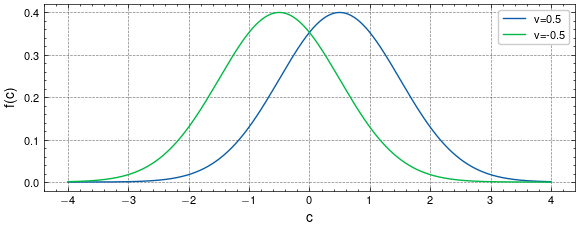

In [31]:
# Plot initial conditions
f_Left = lambda c: (rho_L / np.sqrt(2 * np.pi * theta_L)) * np.exp(-(c - v_L) ** 2 / (2 * theta_L))
f_Right = lambda c: (rho_R / np.sqrt(2 * np.pi * theta_R)) * np.exp(-(c - v_R) ** 2 / (2 * theta_R))

fig, axs = plt.subplots()
c_vals = np.linspace(-4, 4, 500)
axs.plot(c_vals, [f_Left(c) for c in c_vals], label=f'v={v_L}')
axs.plot(c_vals, [f_Right(c) for c in c_vals], label=f'v={v_R}')
axs.legend()
axs.set_xlabel("c")
axs.set_ylabel("f(c)")

fig.tight_layout()
fig.show()

/tmp/ipykernel_13925/1907194590.py:28: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


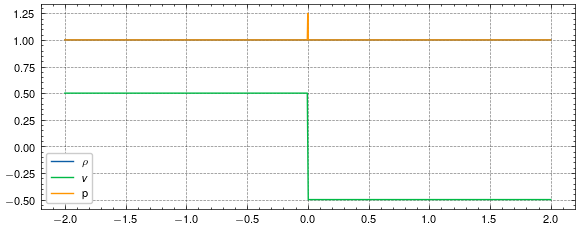

In [32]:
M = 4
closure = 'ExtGram'
Kn = 0.1
source = 'relaxation_source'
time_query = 0 # initial condition
file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

data = read_solution_file(file)

# Build time → timestep mapping
times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
timesteps = np.array(sorted(data.keys()))

sol = interpolate_solution(data, time_query, times, timesteps)
x, u, t = sol["x"], sol["u"], sol["t"]
rho = u[:, 0]
v = u[:, 1] / rho
p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
theta = p / rho

fig, axs = plt.subplots()
axs.plot(x, rho, label='$\\rho$')
axs.plot(x, v, label='$v$')
axs.plot(x, p, label='p')
# axs.plot(x, theta, label='$\\theta$')
axs.legend()
fig.tight_layout()
fig.show()

In [33]:
colors = ['blue', 'orange', 'green', 'red', 'purple']
linestyles = ['--', '-', ':']

In [34]:
class Maxwellian:
    def __init__(self, rho, v, theta):
        self.rho = rho
        self.v = v
        self.theta = theta

    def __call__(self, c):
        return self.rho / np.sqrt(2*np.pi*self.theta) * np.exp(-(c-self.v)**2 / (2*self.theta))

def f0(f_left, f_right, x, c):
    x_arr, c_arr = np.broadcast_arrays(np.asarray(x), np.asarray(c))
    return np.where(x_arr < 0, f_left(c_arr), f_right(c_arr))
    
def f(f_left, f_right, x, c, t):
    return f0(f_left, f_right, x - c*t, c)

maxwellian_L = Maxwellian(rho_L, v_L, theta_L)
maxwellian_R = Maxwellian(rho_R, v_R, theta_R)

Nx = np.linspace(-6, 6, 10_000)
Nc = np.linspace(-10, 10, 10_000)
T = 0.3
f_T = f(maxwellian_L, maxwellian_R, Nx, Nc[:, None], T)
rho_T = np.trapz(f_T, Nc, axis=0)
v_T = np.trapz(Nc[:, None] * f_T, Nc, axis=0) / rho_T
theta_T = np.trapz((Nc[:, None] - v_T)**2 * f_T, Nc, axis=0) / rho_T
p_T = theta_T * rho_T
Q_T = np.trapz((Nc[:, None] - v_T)**3 * f_T, Nc, axis=0)

/tmp/ipykernel_13925/2454071767.py:62: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_13925/2454071767.py:62: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


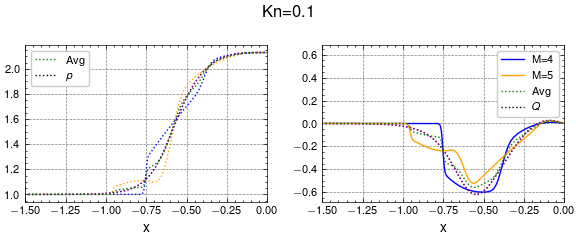

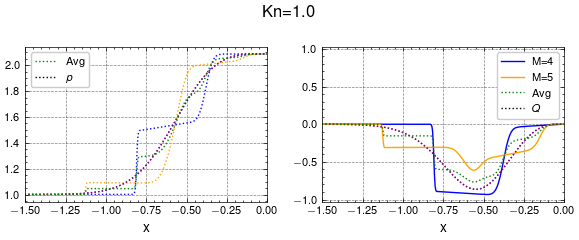

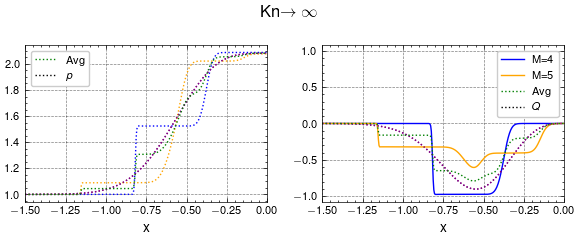

In [35]:
Moments = [4, 5]
closures = ["Gram", "ExtGram"]
for i in range(len(Knudsen)):
    Kn = Knudsen[i]
    source = source_vec[i]
    fig, axs = plt.subplots(1, 2)
    if source == "relaxation_source":
        fig.suptitle(f'Kn={Kn}')
    else:
        fig.suptitle(f'Kn$\\to \\infty$')
        
    [ax.set_xlim(-1.5, 0)  for ax in axs]
    [ax.set_xlabel('x') for ax in axs]
    p_vector, q_vector = [], []
    for m, M in enumerate(Moments):
        file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

        x, u, _ = sol_final(file)
        rho = u[:, 0]
        v = u[:, 1] / rho
        p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
        theta = p / rho

        axs[0].plot(x, p, color=colors[m], ls=linestyles[2])
        p_vector.append(p)

        file_prim = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_prim.tsv"

        x, w, _ = sol_final(file_prim)
        Q = w[:, 3]
        q_vector.append(Q)

        axs[1].plot(x, Q, color=colors[m], label=f'M={M}')

        # BGK
        if source == "relaxation_source":
            # continue
            data_bgk = pd.read_csv(f'../out/Riemann1D/BGK/bgk_solution_N{N}_c_l{c_L}_c_u{c_R}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_bgk}_polydeg{polydeg}_x_left{x_left_BGK}_x_right{x_right_BGK}_rho_v_p.csv')

            x_bgk = data_bgk['x'].to_numpy()
            p_bgk = data_bgk['p'].to_numpy()
            q_bgk = data_bgk['q'].to_numpy()
            
            axs[0].plot(x_bgk, p_bgk, color=colors[4], ls=linestyles[2])
            axs[1].plot(x_bgk, q_bgk, color=colors[4], ls=linestyles[2])
        else: 
            axs[0].plot(Nx, p_T, color=colors[4], ls=linestyles[2])
            axs[1].plot(Nx, Q_T, color=colors[4], ls=linestyles[2])

    p_mean = np.mean(p_vector, axis=0)
    axs[0].plot(x, p_mean, color=colors[2], ls=linestyles[2], label='Avg')
    q_mean = np.mean(q_vector, axis=0)
    axs[1].plot(x, q_mean, color=colors[2], ls=linestyles[2], label='Avg')
    
    axs[0].plot([], [], color='black', ls=linestyles[2], label='$p$')

    axs[1].plot([], [], color='black', ls=linestyles[2], label='$Q$')

    [ax.legend() for ax in axs]

    fig.tight_layout()
    fig.show()

/tmp/ipykernel_13925/1630680696.py:62: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_13925/1630680696.py:62: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


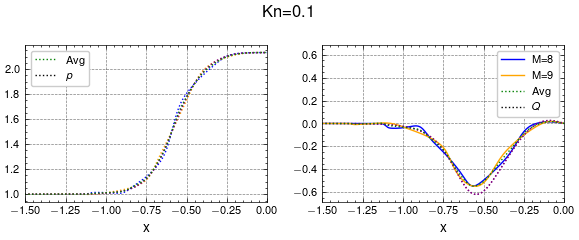

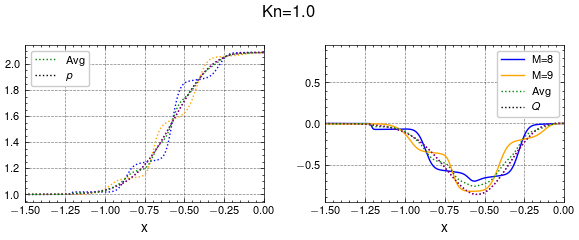

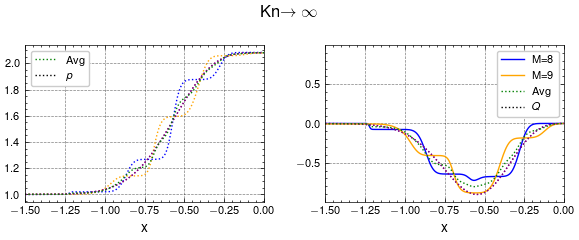

In [39]:
Moments = [8, 9]
closures = ["Gram", "ExtGram"]
for i in range(len(Knudsen)):
    Kn = Knudsen[i]
    source = source_vec[i]
    fig, axs = plt.subplots(1, 2)
    if source == "relaxation_source":
        fig.suptitle(f'Kn={Kn}')
    else:
        fig.suptitle(f'Kn$\\to \\infty$')
        
    [ax.set_xlim(-1.5, 0)  for ax in axs]
    [ax.set_xlabel('x') for ax in axs]
    p_vector, q_vector = [], []
    for m, M in enumerate(Moments):
        file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

        x, u, _ = sol_final(file)
        rho = u[:, 0]
        v = u[:, 1] / rho
        p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
        theta = p / rho

        axs[0].plot(x, p, color=colors[m], ls=linestyles[2])
        p_vector.append(p)

        file_prim = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_prim.tsv"

        x, w, _ = sol_final(file_prim)
        Q = w[:, 3]
        q_vector.append(Q)

        axs[1].plot(x, Q, color=colors[m], label=f'M={M}')

        # BGK
        if source == "relaxation_source":
            # continue
            data_bgk = pd.read_csv(f'../out/Riemann1D/BGK/bgk_solution_N{N}_c_l{c_L}_c_u{c_R}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_bgk}_polydeg{polydeg}_x_left{x_left_BGK}_x_right{x_right_BGK}_rho_v_p.csv')

            x_bgk = data_bgk['x'].to_numpy()
            p_bgk = data_bgk['p'].to_numpy()
            q_bgk = data_bgk['q'].to_numpy()
            
            axs[0].plot(x_bgk, p_bgk, color=colors[4], ls=linestyles[2])
            axs[1].plot(x_bgk, q_bgk, color=colors[4], ls=linestyles[2])
        else: 
            axs[0].plot(Nx, p_T, color=colors[4], ls=linestyles[2])
            axs[1].plot(Nx, Q_T, color=colors[4], ls=linestyles[2])

    p_mean = np.mean(p_vector, axis=0)
    axs[0].plot(x, p_mean, color=colors[2], ls=linestyles[2], label='Avg')
    q_mean = np.mean(q_vector, axis=0)
    axs[1].plot(x, q_mean, color=colors[2], ls=linestyles[2], label='Avg')
    
    axs[0].plot([], [], color='black', ls=linestyles[2], label='$p$')

    axs[1].plot([], [], color='black', ls=linestyles[2], label='$Q$')

    [ax.legend() for ax in axs]

    fig.tight_layout()
    fig.show()